In [1]:
import icechunk
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from srm import catalog
from srm.cache import ArtifactCache
from srm.config import _icechunk_storage_for_path
from srm.qa_flags import (
    flag_global_exceedances,
    flag_rsds_above_max,
flag_outliers,
    get_data,
    parse_tag,
    plot_flags,
    run_flag_loop,
    write_individual_flags,
)

In [2]:
from srm.downscaling_utils import interpolate_coarse_to_fine_grid, interpolate_fine_to_coarse_grid
from srm.qaqc import calculate_distortion_flags, sign_flip_mask

# A. Define what data arrays exist to traverse

In [3]:
# --- Run parameters --------------------------------------------------------
# This regional South-Africa-box run covers three GCMs, each written to its own icechunk store
# (same bucket/branch, named by GCM the same way srm.cache.ArtifactCache names pipeline output
# stores). Looping over GCMS -- rather than hardcoding one, as this notebook used to -- is what
# lets every leaf be compared against ITS OWN GCM's catalog and lineage instead of silently
# reusing whichever GCM happened to be hardcoded.


VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]  # , "hurs"]

In [4]:
GCMS = ["CESM2-WACCM"]

#BRANCH = "full-regional-run-issue-534"
#ROOT_DIR = "s3://carbonplan-scratch/srm/output/qa/"
#STORE_SUBSET_BOUNDS = (-38.0, -19.0, 13.0, 36.0)
#STORE_SUBSET_ID = ArtifactCache._get_subset_id(STORE_SUBSET_BOUNDS)

BRANCH = "v0.13.0"
ROOT_DIR="s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/"
STORE_SUBSET_ID="global"

In [5]:
def store_uri(gcm: str, root_dir: str = ROOT_DIR) -> str:
    return f"{root_dir}{gcm}-ERA5-{STORE_SUBSET_ID}.icechunk"

In [6]:
trees: dict[str, xr.DataTree] = {}
open_errors: dict[str, str] = {}

for gcm in GCMS:
    try:
        repo = icechunk.Repository.open(_icechunk_storage_for_path(store_uri(gcm)))
        session = repo.readonly_session(BRANCH) if BRANCH else repo.readonly_session()
        trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks={})
    except Exception as exc:  # noqa: BLE001  # report every failure, do not stop at the first
        open_errors[gcm] = f"{type(exc).__name__}: {exc}"

for gcm, err in open_errors.items():
    print(f"FAILED to open {gcm}: {err}")

# GCMs whose store actually opened. A GCM whose run is still in flight is skipped here rather
# than failing the whole notebook, so this check can be run against a partially-landed run.
OPEN_GCMS = tuple(gcm for gcm in GCMS if gcm in trees)
print(f"opened {len(OPEN_GCMS)}/{len(GCMS)} stores on branch {BRANCH!r}: {', '.join(OPEN_GCMS)}")

trees[OPEN_GCMS[0]]

opened 1/1 stores on branch 'v0.13.0': CESM2-WACCM


<xarray.DataTree>
Group: /
├── Group: /debiased_coarse
│   ├── Group: /debiased_coarse/g6_1p5k
│   │   ├── Group: /debiased_coarse/g6_1p5k/tasmax
│   │   │   ├── Group: /debiased_coarse/g6_1p5k/tasmax/002
│   │   │   │       Dimensions:  (time: 18263, lat: 192, lon: 288)
│   │   │   │       Coordinates:
│   │   │   │         * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │   │         * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
│   │   │   │         * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
│   │   │   │       Data variables:
│   │   │   │           tasmax   (time, lat, lon) float32 4GB dask.array<chunksize=(8000, 8, 16), meta=np.ndarray>
│   │   │   │       Attributes: (12/17)
│   │   │   │           Conventions:                                 CF-1.8
│   │   │   │           institution:                                 CarbonPlan
│   │   │   │           history:                                     2026-08-07T19:00:09Z: BCSD d...
│   │   │   │           srm_downscaling:version:                     0.13.0
│   │   │   │           srm_downscaling:gcm:                         CESM2-WACCM
│   │   │   │           srm_downscaling:scenario:                    G6-1.5K
│   │   │   │           ...                                          ...
│   │   │   │           srm_downscaling:bias_correction_method:      nonparametric_hybrid_2sided
│   │   │   │           srm_downscaling:downscaling_method:          additive
│   │   │   │           srm_downscaling:train_period:                1978-2014
│   │   │   │           srm_downscaling:config_hash:                 3de28c3ce09a
│   │   │   │           srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │   │           srm_downscaling:creation_date:               2026-08-07
│   │   │   └── Group: /debiased_coarse/g6_1p5k/tasmax/003
│   │   │           Dimensions:  (time: 18263, lat: 192, lon: 288)
│   │   │           Coordinates:
│   │   │             * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │             * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
│   │   │             * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8
│   │   │           Data variables:
│   │   │               tasmax   (time, lat, lon) float32 4GB dask.array<chunksize=(8000, 8, 16), meta=np.ndarray>
│   │   │           Attributes: (12/17)
│   │   │               Conventions:                                 CF-1.8
│   │   │               institution:                                 CarbonPlan
│   │   │               history:                                     2026-08-07T19:00:32Z: BCSD d...
│   │   │               srm_downscaling:version:                     0.13.0
│   │   │               srm_downscaling:gcm:                         CESM2-WACCM
│   │   │               srm_downscaling:scenario:                    G6-1.5K
│   │   │               ...                                          ...
│   │   │               srm_downscaling:bias_correction_method:      nonparametric_hybrid_2sided
│   │   │               srm_downscaling:downscaling_method:          additive
│   │   │               srm_downscaling:train_period:                1978-2014
│   │   │               srm_downscaling:config_hash:                 85fb7672040a
│   │   │               srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │               srm_downscaling:creation_date:               2026-08-07
│   │   ├── Group: /debiased_coarse/g6_1p5k/hurs
│   │   │   ├── Group: /debiased_coarse/g6_1p5k/hurs/002
│   │   │   │       Dimensions:  (time: 18263, lat: 192, lon: 288)
│   │   │   │       Coordinates:
│   │   │   │         * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │   │         * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.0

In [7]:
gcms, scenarios, variables, ensembles = [], [], [], []

for gcm in OPEN_GCMS:
    tree = trees[gcm]
    for scenario_name, scenario_node in tree.children.items():
        for var_name, var_node in scenario_node.children.items():
            for ens_name, ens_node in var_node.children.items():
                gcms.append(gcm)
                scenarios.append(scenario_name)
                variables.append(var_name)
                ensembles.append(ens_name)

print(f"{len(gcms)} leaves across {len(OPEN_GCMS)} GCMs")

71 leaves across 1 GCMs


In [8]:
keep_idx = [i for i, s in enumerate(scenarios) if s != "debiased_coarse"]
gcms = [gcms[i] for i in keep_idx]
scenarios = [scenarios[i] for i in keep_idx]
variables = [variables[i] for i in keep_idx]
ensembles = [ensembles[i] for i in keep_idx]

keep_idx = [i for i, v in enumerate(variables) if v != "dtr"]
gcms = [gcms[i] for i in keep_idx]
scenarios = [scenarios[i] for i in keep_idx]
variables = [variables[i] for i in keep_idx]
ensembles = [ensembles[i] for i in keep_idx]

keep_idx = [i for i, v in enumerate(variables) if v != "hurs"]
gcms = [gcms[i] for i in keep_idx]
scenarios = [scenarios[i] for i in keep_idx]
variables = [variables[i] for i in keep_idx]
ensembles = [ensembles[i] for i in keep_idx]

In [9]:
tags = []
for i, gcm in enumerate(gcms):
    var = variables[i]
    scenario = scenarios[i]
    ens = ensembles[i]
    tag = f"{gcm}_{var}_{scenario}_{ens}"
    tags.append(tag)

In [10]:
import numpy as np

gcms_np = np.array(gcms)
scenarios_np = np.array(scenarios)
variables_np = np.array(variables)
ensembles_np = np.array(ensembles)
tags_np = np.array(tags)

In [51]:
INTERMEDIATE_FLAG_DIR = "s3://carbonplan-scratch/srm/qaqc/flags/" + STORE_SUBSET_ID + "/"

# Get dataset

In [68]:
def get_intermediate_flags(flag_dir: str, tag: str):
    flag_data = xr.open_zarr(
        flag_dir + tag + ".zarr", consolidated=False
    )
    return flag_data

In [69]:
def combine_intermediate_flags(tag: str,
                               flag_dir: str, 
                               flag_list_time_varying: list,
                               flag_list_time_invariant: list,
                              ):
    """
    This calculates two single binary flags from multiple intermediate flags. The intermediate flags 
    
    """

    flags = get_intermediate_flags(flag_dir=flag_dir, tag=tag)

    ind=0
    for flag_time_varying in flag_list_time_varying:
        if flag_time_varying in flags.variables:
            flag=flags[flag_time_varying]
            if ind==0:
                overall_flag_time_varying=flag
            else:
                overall_flag_time_varying=overall_flag_time_varying+flag
            ind=ind+1
    overall_flag_time_varying=overall_flag_time_varying>0

    ind=0
    for flag_time_invariant in flag_list_time_invariant:
        if flag_time_invariant in flags.variables:
            flag=flags[flag_time_invariant]
            if ind==0:
                overall_flag_time_invariant=flag
            else:
                overall_flag_time_invariant=overall_flag_time_invariant+flag
            ind=ind+1
    overall_flag_time_invariant=overall_flag_time_invariant>0

    return overall_flag_time_varying, overall_flag_time_invariant

In [70]:
FLAG_LIST_TIME_VARYING = ['annual_outlier_flag',
                          'rsds_max_exceeded',
                          'outside_global_plausible_range',
                         'temperature_inconsistency']

FLAG_LIST_TIME_INVARIANT = ['flipped_signssp245_g6_1p5k',
                            'flipped_signhistorical_ssp245',
                            'flipped_signhistorical_g6_1p5k',
                            'trend_distortion_historical_ssp245',
                            'trend_distortion_ssp245_g6_1p5k',
                           'trend_distortion_historical_g6_1p5k']

In [71]:
tag='CESM2-WACCM_rsds_ssp245_003'

[overall_flag_time_varying, overall_flag_time_invariant] = combine_intermediate_flags(tag=tag,
                               flag_dir=INTERMEDIATE_FLAG_DIR,
                               flag_list_time_varying=FLAG_LIST_TIME_VARYING,
                               flag_list_time_invariant=FLAG_LIST_TIME_INVARIANT,
                              )

In [72]:
lat=overall_flag_time_invariant.lat
lon=overall_flag_time_invariant.lon

In [76]:
import numpy as np
import xarray as xr
import pandas as pd
print(len(tags))

for i, tag in enumerate(tags):
    print(tag)
    # Get flags
    print("calculating flags")
    [overall_flag_time_varying, overall_flag_time_invariant] = combine_intermediate_flags(tag=tag,
                               flag_dir=INTERMEDIATE_FLAG_DIR,
                               flag_list_time_varying=FLAG_LIST_TIME_VARYING,
                               flag_list_time_invariant=FLAG_LIST_TIME_INVARIANT,
                              )

    # TO DO: write these flags out as variables, uint8
    overall_flag_time_varying.compute()
    overall_flag_time_invariant.compute()

31
CESM2-WACCM_tasmin_g6_1p5k_002
calculating flags
CESM2-WACCM_tasmin_g6_1p5k_003
calculating flags
CESM2-WACCM_pr_g6_1p5k_002
calculating flags
CESM2-WACCM_pr_g6_1p5k_003
calculating flags
CESM2-WACCM_rsds_g6_1p5k_002
calculating flags
CESM2-WACCM_rsds_g6_1p5k_003
calculating flags
CESM2-WACCM_tas_g6_1p5k_002
calculating flags
CESM2-WACCM_tas_g6_1p5k_003
calculating flags
CESM2-WACCM_tasmax_g6_1p5k_002
calculating flags
CESM2-WACCM_tasmax_g6_1p5k_003
calculating flags
CESM2-WACCM_pr_g6_1p5k_end_002
calculating flags


UnboundLocalError: cannot access local variable 'overall_flag_time_invariant' where it is not associated with a value

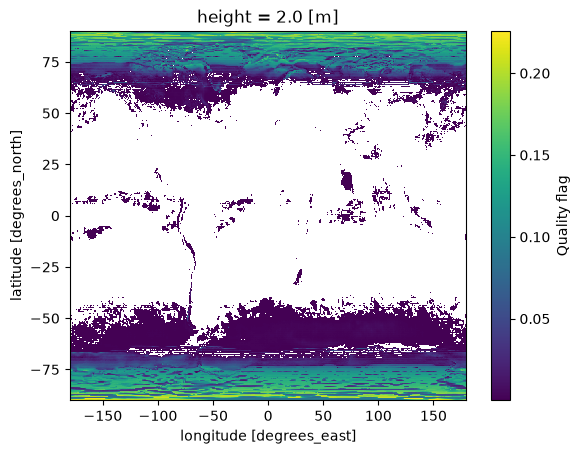

In [67]:
plt.title('Fraction of time steps with time-varying quality flag')
freq_time_flags = overall_flag_time_varying.mean(dim='time')
freq_time_flags.where(freq_time_flags>0).plot()

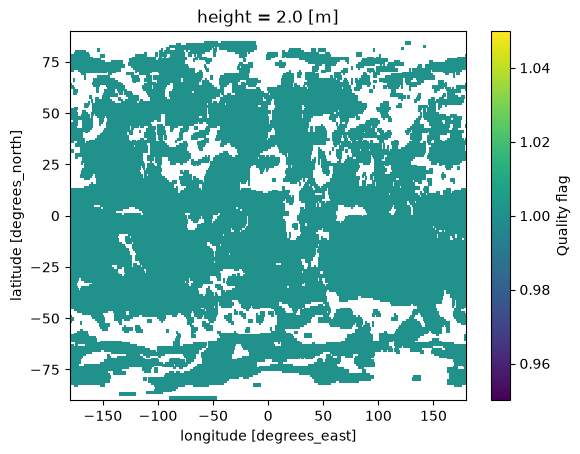

In [64]:
overall_flag_time_invariant.where(overall_flag_time_invariant>0).plot()